#Example from DL Diagnostics ifes WP 2021 by Frank Lehrbass

In [1]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

print(torch.__version__)

cuda = True
if not torch.cuda.is_available():
    cuda = False
device = torch.device("cuda" if cuda else "cpu")

ModuleNotFoundError: No module named 'torch'

torch.Size([100])


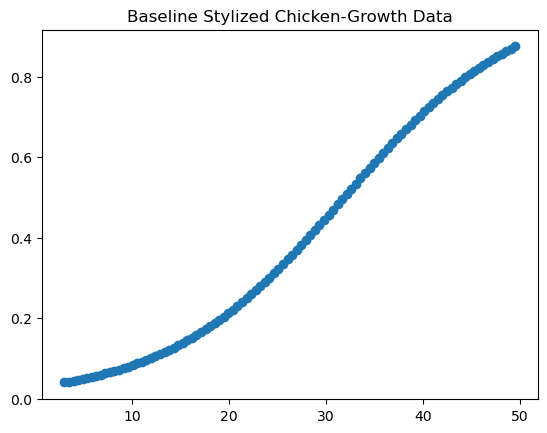

In [2]:
# data generation
seed=2023
#helper fct
def set_seed_everywhere(seed, cuda):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed_all(seed)    
        
set_seed_everywhere(seed,cuda)
#set paras as in DL Diag ifes WP
n=100 #size of training sample

#original chicken-growth data
b0=3.50
b1=-0.11
s=0.05

start_obs = 3
end_obs = 50
no_obs = n
t_x = torch.arange(start_obs, end_obs, step = (end_obs-start_obs)/no_obs) #Returns a 1-D tensor
print(t_x.shape)
t_y = 1/(1+torch.exp(b0+b1*t_x))

plt.scatter(t_x.data.numpy(), t_y.data.numpy())
plt.title('Baseline Stylized Chicken-Growth Data')
plt.show()

In [4]:
eps_mean = torch.zeros(n)
t_y = torch.add(t_y,torch.normal(eps_mean,s))#When the shapes do not match, 
#the shape of mean is used as the shape for the returned output tensor
t_y = torch.maximum(t_y,torch.zeros(n)) #avoid negative weights
t_y = torch.minimum(t_y,torch.ones(n)) #avoid y outside of scope of sigmoid
#plt.scatter(t_x.data.numpy(), t_y.data.numpy())
plt.scatter(t_x, t_y)
plt.title('Stylized Chicken-Growth Data incl. error term')
plt.show()
print(t_x.shape, t_y.shape)
#NOTE that u cannot use this for training! YOU need matrix with n rows and one column
#to get this follow DL Book p. 155
t_x = t_x.clone().detach().unsqueeze(1)#old style torch.tensor(t_x) leads to warning
print(t_x.shape)
t_y = t_y.clone().detach().unsqueeze(1)

NameError: name 'torch' is not defined

In [3]:
p_val = 0.2 #percentage for validation

n_samples = t_x.shape[0]
n_val = int(p_val * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices  # <1>

train_t_x = t_x[train_indices]
train_t_y = t_y[train_indices]
val_t_x = t_x[val_indices]
val_t_y = t_y[val_indices]

NameError: name 't_x' is not defined

In [5]:
n_input = 1
n_hidden = 1
n_out = 1

#how to construct models out of classes read 6.2.1 in "DL with Pytorch", Stevens et al
mlp_chicken_pt = nn.Sequential(nn.Linear(n_input, n_hidden),
                      nn.Sigmoid())#defines the graph
#linear is a+bX, then follows a hidden layer of n_hidden-s sigmoids, lienarly fed into a single sigmoid output neuron
total_params = sum(p.numel() for p in mlp_chicken_pt.parameters())
print(f"Total number of parameters in Perceptron: {total_params:,}")

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_chicken_pt.parameters(), lr=0.02)
losses_train = []
losses_val = []
start_time = time.time()

Total number of parameters in Perceptron: 2


In [5]:
n_epoch = 1000

def generic_training_loop(n_epochs, optimizer, model, loss_fn, train_t_u, val_t_u,train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u) #all details are in model
        train_loss = loss_fn(train_t_p, train_t_c) #and the loss function
        losses_train.append(train_loss.item())                    
        with torch.no_grad(): # <1>
            val_t_p = model(val_t_u)
            val_loss = loss_fn(val_t_p, val_t_c)
            losses_val.append(val_loss.item()) 
            assert val_loss.requires_grad == False 
            
        optimizer.zero_grad()
        train_loss.backward() 
        optimizer.step()
        if epoch <= 10 or epoch % 100 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                  f" Validation loss {val_loss.item():.4f}")
    
    return 

generic_training_loop(n_epochs = n_epoch, optimizer = optimizer, model = mlp_chicken_pt,
                      loss_fn = loss_fn, train_t_u = train_t_x, val_t_u = val_t_x, 
                      train_t_c = train_t_y, val_t_c = val_t_y)

NameError: name 'optimizer' is not defined

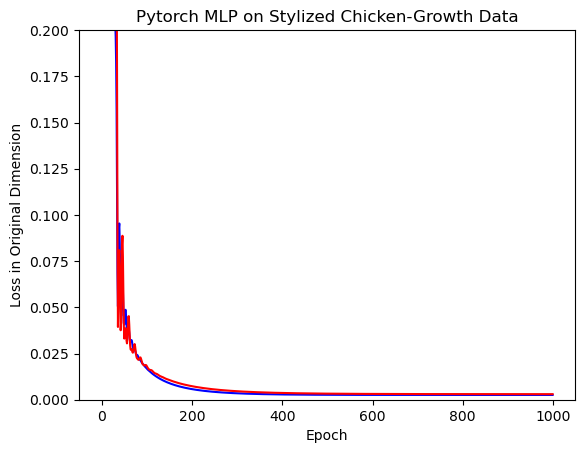

In [11]:
t_ctr = torch.arange(0, n_epoch, step = 1)
t_ctr = t_ctr.clone().detach().unsqueeze(1)
plt.plot(t_ctr, losses_train, 'b') # plotting separately 
plt.plot(t_ctr, losses_val, 'r') 
plt.ylabel('Loss in Original Dimension')
plt.xlabel('Epoch')
plt.title('Pytorch MLP on Stylized Chicken-Growth Data')
plt.ylim(top = 0.2)
plt.ylim(bottom = 0)
plt.show()


 Mean of Resis:  -0.0010269269

 Stdev of Resis vs Stdev of Error:  0.051104028 0.05


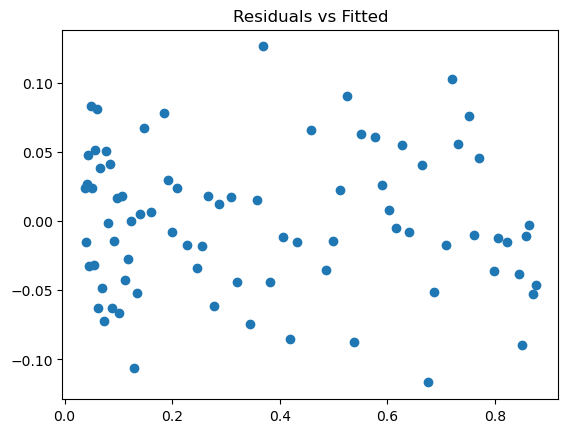

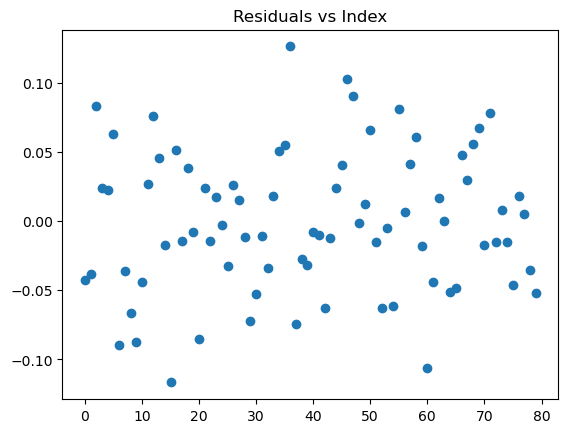

In [12]:
#diags
t_fc = mlp_chicken_pt(train_t_x).detach().numpy()
t_resi = train_t_y-t_fc

#summary stats
print("\n Mean of Resis: ", torch.mean(t_resi).numpy())

print("\n Stdev of Resis vs Stdev of Error: ", torch.std(t_resi).numpy(), s)

plt.scatter(t_fc, t_resi.data.numpy())
plt.title('Residuals vs Fitted')
plt.show()

t_ctr = torch.arange(0, train_t_x.shape[0], step = 1)
t_ctr = t_ctr.clone().detach().unsqueeze(1)
plt.scatter(t_ctr, t_resi)
plt.title('Residuals vs Index')
plt.show()

In [13]:
#deep dive into net
print("\n Params of Pytorch mlp_chicken_pt")
for name, param in mlp_chicken_pt.named_parameters():
    print(name, param.shape)
    print(name, param.data.numpy())
print("\nA specific forecast")
print(t_fc[0])#this is the first forecast of net given x[0]
#print(mlp_chicken_pt.bias())
print("\nThe ingredients")
print(train_t_x[0])
print(list(mlp_chicken_pt.parameters())[0])
print(list(mlp_chicken_pt.parameters())[1])
t_by_feet = list(mlp_chicken_pt.parameters())[1] + list(mlp_chicken_pt.parameters())[0] * train_t_x[0]
t_by_feet = t_by_feet.sigmoid()
print("\nAfter cooking we get", t_by_feet)


 Params of Pytorch mlp_chicken_pt
0.weight torch.Size([1, 1])
0.weight [[0.11273148]]
0.bias torch.Size([1])
0.bias [-3.5769615]

A specific forecast
[0.11173666]

The ingredients
tensor([13.3400])
Parameter containing:
tensor([[0.1127]], requires_grad=True)
Parameter containing:
tensor([-3.5770], requires_grad=True)

After cooking we get tensor([[0.1117]], grad_fn=<SigmoidBackward0>)


In [14]:
print("\n Params of Pytorch mlp_chicken_pt")
for name, param in mlp_chicken_pt.named_parameters():
    print(name, param.shape)
    print(name, param.data.numpy())
    
print("\n Same order as PyTorch output:", -b0, -b1)
print('\n Training AT HOME needed: %s seconds---' % (time.time() - start_time))
print("\nXXX DONE XXX")


 Params of Pytorch mlp_chicken_pt
0.weight torch.Size([1, 1])
0.weight [[0.11273148]]
0.bias torch.Size([1])
0.bias [-3.5769615]

 Same order as PyTorch output: -3.5 0.11

 Training AT HOME needed: 1.1074507236480713 seconds---

XXX DONE XXX
